In [56]:
from final_data import titanic_data, titanic_test_data, titanic_gender_submission
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

ImportError: cannot import name 'titanic_test_data' from 'final_data' (f:\download\python 3.10.11\exercise\Library\scikit-learn\project\Titanic - Machine Learning from Disaster\Baseline Models\final_data.py)

In [ ]:
data = titanic_data()
X = data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=19)

In [ ]:
print(X_train.dtypes)

Pclass           int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked        object
Gender          object
FareGroup     category
AgeGroup      category
FamilySize       int64
dtype: object


In [ ]:
numeric_features = [
    'Pclass',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'FamilySize',
    'FarePerPerson',
    'IsAlone'
]

categorical_features = [
    'Embarked',
    'Gender',
    'FareGroup',
    'AgeGroup'
]

In [ ]:
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipe_line = Pipeline([
    ('preprocessor', preprocessor),
    ('randomforest', RandomForestClassifier())
], verbose=True)

pipe_line.fit(X_train, y_train)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.4s


,steps,"[('preprocessor', ...), ('randomforest', ...)]"
,transform_input,None
,memory,None
,verbose,True
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
param_grid = {
    'randomforest__n_estimators': [90, 100, 200],
    'randomforest__criterion': ['gini', 'entropy'],
    'randomforest__ccp_alpha': [0, 0.001, 0.005, 0.01],
    'randomforest__max_depth': [3, 6, 8, 10],
    'randomforest__max_samples': [0.5, 0.7, 0.9, 1.0]
}

In [ ]:
grid = GridSearchCV(estimator=pipe_line, param_grid=param_grid, cv=5, verbose=1, scoring='accuracy')
grid.fit(X_train, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.5s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.3s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.3s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ...... (step 2 of 2) Processing randomforest, total=   0.2s
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   0.0s
[Pipeline] ..

KeyboardInterrupt: 

In [ ]:
grid.best_params_

{'randomforest__ccp_alpha': 0.005,
 'randomforest__criterion': 'entropy',
 'randomforest__max_depth': 10,
 'randomforest__max_samples': 0.7,
 'randomforest__n_estimators': 200}

In [ ]:
grid.best_score_

np.float64(0.8210733452593917)

In [ ]:
test_data = titanic_test_data()
gender_submission_data = titanic_gender_submission()
X_test = test_data[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
       'Gender', 'FareGroup', 'AgeGroup', 'FamilySize', 'FarePerPerson', 'IsAlone']]
y_test = gender_submission_data['Survived']

In [ ]:
test_accuracy = grid.score(X_test, y_test)
test_accuracy

0.8611111111111112

In [ ]:
pred = grid.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[126   8]
 [ 22  60]]
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       134
           1       0.88      0.73      0.80        82

    accuracy                           0.86       216
   macro avg       0.87      0.84      0.85       216
weighted avg       0.86      0.86      0.86       216



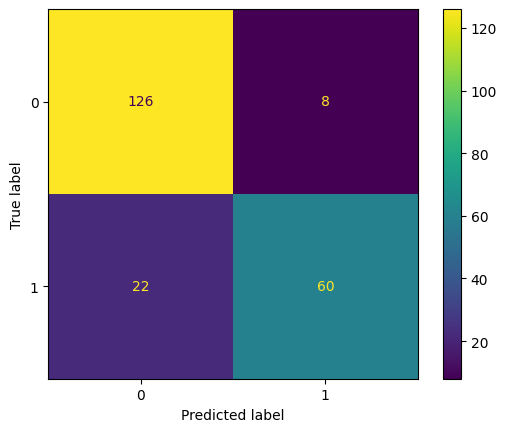

In [ ]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred), display_labels=grid.classes_).plot()